## Gráficos de Barra e de Área Empilhados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Nesta aula usaremos o Pandas para criar gráficos de barra e de área diretamente a partir de um dataframe.

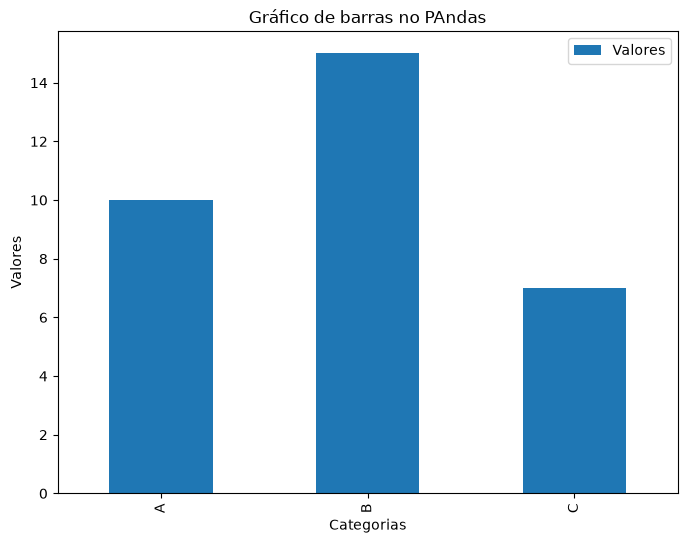

In [3]:
df = pd.DataFrame({'Categorias': ['A', 'B','C'], 
                   'Valores': [10,15,7]})
plt.rcParams['figure.figsize'] = [8,6]
df.plot(kind='bar', x='Categorias', y='Valores', legend='a')
plt.xlabel('Categorias')
plt.ylabel('Valores')
plt.title('Gráfico de barras no PAndas')
plt.show()

Agora, usaremos um dataset que exibe os dados sobre crimes na região de Washington DC. Veremos como agregar esses dados de modo a possibilitar gerar gráficos de barra e de área que ilustram a evolução de diferentes tipos de crime no decorrer dos anos.

Vamos começar criando o dataframe a partir de um arquivo csv.

In [4]:
df = pd.read_csv('datasets/washingtonDCCrime.csv')

In [5]:
df.head(30)

,Year,Crime,Rate
0,2005,Murder,33.5
1,2006,Murder,29.1
2,2007,Murder,30.8
3,2008,Murder,31.4
4,2009,Murder,24.2
5,2010,Murder,21.8
6,2011,Murder,17.4
7,2012,Murder,13.9
8,2013,Murder,15.9
9,2014,Murder,15.9


Usando a função crosstab do pacote pandas vamos agrupar os crimes por ano(Year) / tipo do crime (Crime). Note que Rate é a taxa de crimes por 100 mil habitantes.

In [6]:

"agrupe por ano os crimes,  olhando taxas somadas"
summary = pd.crosstab(df['Year'], df['Crime'], values=df['Rate'], aggfunc=np.sum)
summary

Crime,Aggravated Assault,Murder,Rape,Robery
Year,,,,
2005,682.2,33.5,28.5,635.7
2006,789.1,29.1,31.8,658.4
2007,626.7,30.8,32.6,725.0
2008,626.4,31.4,31.4,748.5
2009,565.3,24.2,25.0,734.4
2010,559.1,21.8,30.9,715.0
2011,494.0,17.4,27.9,661.4
2012,553.3,13.9,37.3,637.3
2013,590.8,15.9,45.8,628.9


Vamos agora plotar um gráfico de barras a partir do sumário gerado.

Text(0.5, 1.0, 'Stacked')

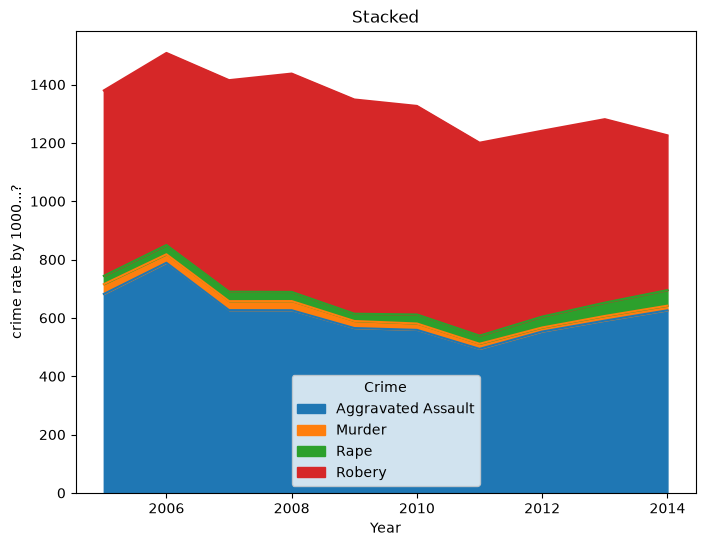

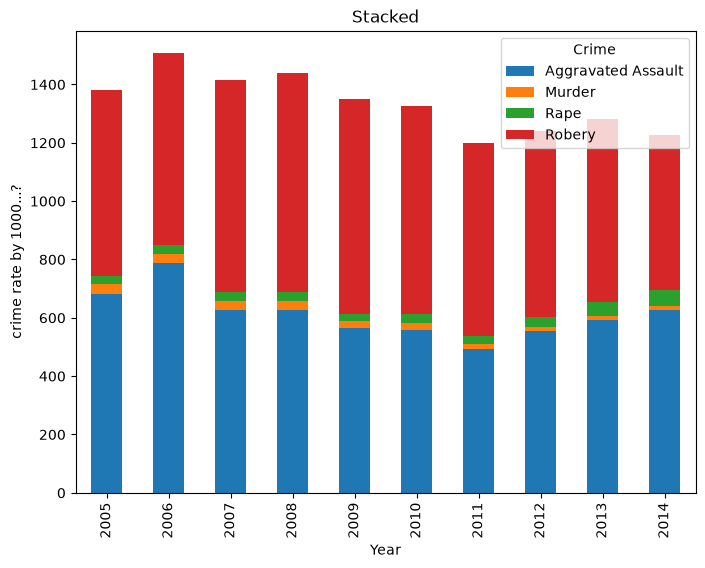

In [7]:
summary.plot(kind='area', stacked=True)
plt.xlabel("Year")
plt.ylabel("crime rate by 1000...?")
plt.title('Stacked')

summary.plot(kind='bar', stacked=True)
plt.xlabel("Year")
plt.ylabel("crime rate by 1000...?")
plt.title('Stacked')

É possível melhorar o aspecto do gráfico customizando o tamanho da fonte, a posição das legendas, etc. Para tanto é necessário usar set_context do pacote seaborn.

Text(0.5, 1.0, 'Stacked area plot of whashington dc crimes')

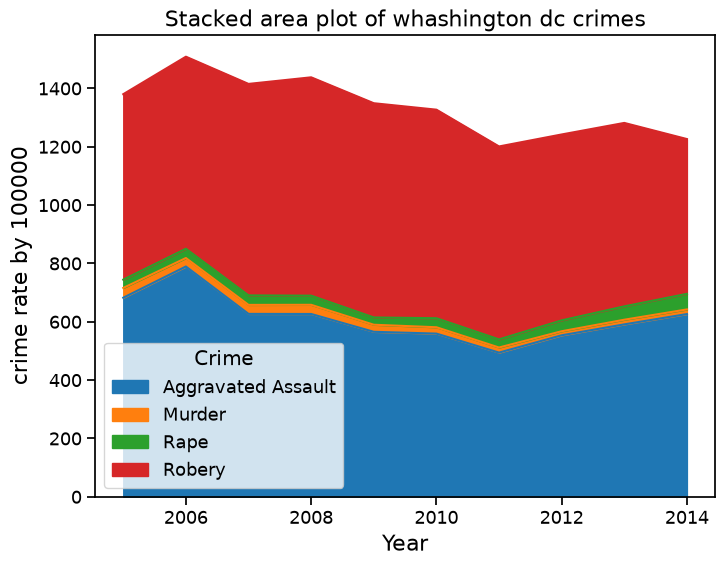

In [8]:
sns.set_context("notebook", font_scale=1.2, rc={"font.size":12, 'axes.titlesize':16, 'axes.labelsize':16})
summary.plot(kind='area', stacked=True)
plt.xlabel("Year")
plt.ylabel("crime rate by 100000")
plt.title('Stacked area plot of whashington dc crimes')

Por fim, para gerar um gráfico de barras, basta trocar 'area' por 'bar'.

Text(0.5, 1.0, 'Stacked bar plot of whashington dc crimes')

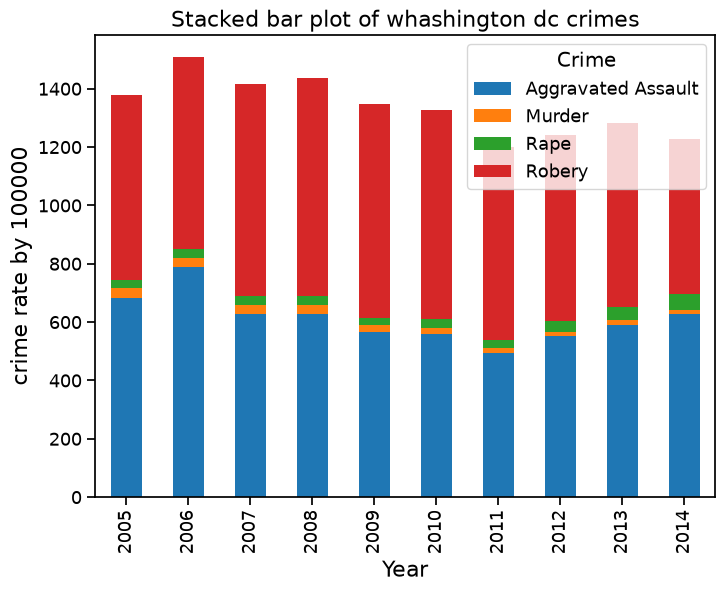

In [9]:
sns.set_context("notebook", font_scale=1.2, rc={"font.size":12, 'axes.titlesize':16, 'axes.labelsize':16})
summary.plot(kind='bar', stacked=True)
plt.xlabel("Year")
plt.ylabel("crime rate by 100000")
plt.title('Stacked bar plot of whashington dc crimes')

### Exercício 1
Neste exercício usaremos o dataset GDP_by_Country, que mostra o PIB de todos os países do globo entre os anos de 1999 e 2022.

In [17]:
df_gdp = pd.read_csv('datasets/GDP_by_Country.csv')
df_gdp.head()

,Country,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,"Afghanistan, Rep. of.",0,0,0,4.084,4.585,5.971,7.309,8.399,9.892,...,21.555,24.304,0,0,0,0,0,0,0,0
1,Albania,3.444,3.695,4.096,4.456,5.6,7.452,8.376,9.133,10.163,...,14.91,16.053,11.591,12.204,13.214,14.341,15.553,16.996,16.77,18.012
2,Algeria,48.845,54.749,55.181,57.053,68.013,85.016,102.38,114.322,116.158,...,190.432,203.449,175.077,181.71,192.256,202.179,210.906,219.16,163.812,168.195
3,Angola,6.153,9.135,8.936,11.386,13.956,19.8,30.632,43.759,55.37,...,136.415,151.089,102.011,98.815,105.369,112.533,119.403,127.15,70.339,74.953
4,Antigua and Barbuda,0.652,0.678,0.71,0.718,0.754,0.818,0.875,0.962,1.026,...,1.404,1.494,1.285,1.328,1.386,1.458,1.536,1.617,1.405,1.534


Vamos fazer alguns ajustes no dataframe para facilitar sua manipulação:
1) Colocar o nome do país como índice
2) Ajustar os dados numéricos para float

In [18]:
df_gdp.set_index('Country', inplace=True)
#ajuste do formato numerico para float
df_gdp = df_gdp.replace(',','', regex=True)
df_gdp = df_gdp.astype(float)

df_gdp.head()

,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Country,,,,,,,,,,,,,,,,,,,,,
"Afghanistan, Rep. of.",0.000,0.000,0.000,4.084,4.585,5.971,7.309,8.399,9.892,11.513,...,21.555,24.304,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Albania,3.444,3.695,4.096,4.456,5.600,7.452,8.376,9.133,10.163,11.131,...,14.910,16.053,11.591,12.204,13.214,14.341,15.553,16.996,16.770,18.012
Algeria,48.845,54.749,55.181,57.053,68.013,85.016,102.380,114.322,116.158,126.889,...,190.432,203.449,175.077,181.710,192.256,202.179,210.906,219.160,163.812,168.195
Angola,6.153,9.135,8.936,11.386,13.956,19.800,30.632,43.759,55.370,67.608,...,136.415,151.089,102.011,98.815,105.369,112.533,119.403,127.150,70.339,74.953
Antigua and Barbuda,0.652,0.678,0.710,0.718,0.754,0.818,0.875,0.962,1.026,1.074,...,1.404,1.494,1.285,1.328,1.386,1.458,1.536,1.617,1.405,1.534


Vamos agora selecionar apenas o PIB anual do Brasil.

In [12]:
df_Brasil = df_gdp.loc['Brazil']
df_Brasil.head()

1999    586.922
2000    644.283
2001    554.410
2002    505.712
2003    552.239
Name: Brazil, dtype: float64

Agora podemos plotar um gráfico de barras e observar a evolução do PIB do Brasil ao longo dos anos.

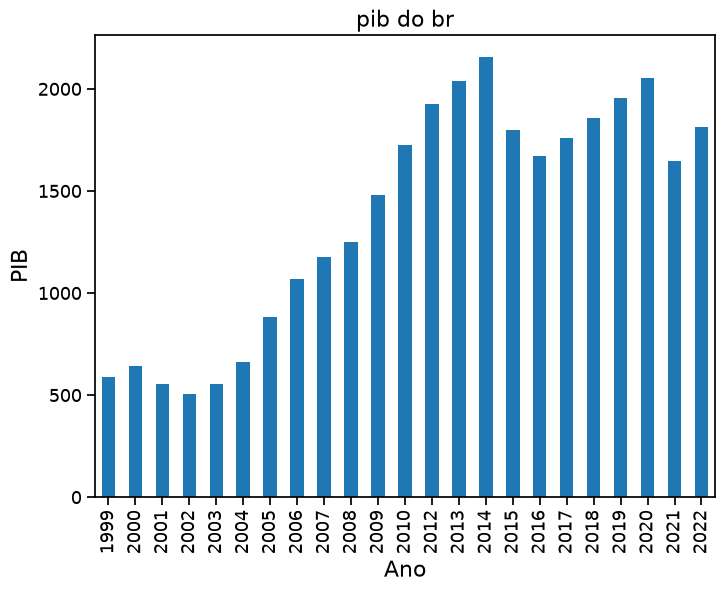

In [13]:
df_Brasil.plot(kind='bar')
plt.xlabel('Ano')
plt.ylabel('PIB')
plt.title('pib do br')
plt.show()

### Exercício 2
Plote um gráfico que mostre os 15 países com maior PIB no ano de 2022.

In [14]:
df_gdp_2022 = df_gdp[['2022']]

df_gdp_2022_sorted = df_gdp_2022.sort_values(by='2022', ascending=False)

df_final = df_gdp_2022_sorted.head(15)
df_final


,2022
Country,
United States,24796.08
China,18463.13
Japan,5383.68
Germany,4557.35
United Kingdom,3442.21
India,3250.08
France,3140.03
Italy,2272.27
Canada,2189.79


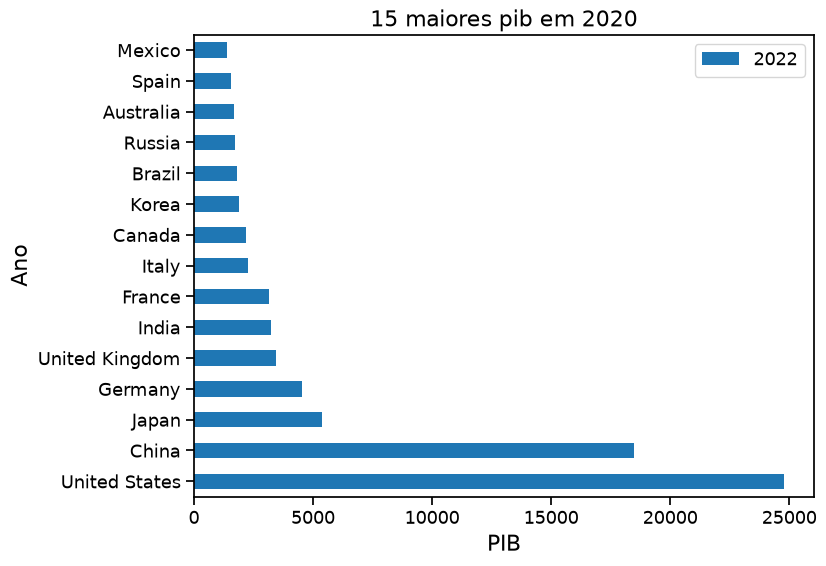

In [15]:
#- horizontal
df_final.plot(kind='barh')
plt.ylabel('Ano')
plt.xlabel('PIB')
plt.title('15 maiores pib em 2020')
plt.show()